# Bidding Predictions for Construction

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
from lightgbm import LGBMRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
print("Setup complete.")

Setup complete.


## 2. Load and Explore the Dataset

The competition provides data at two levels:
- **Pay-item level** (`raw_train`, `raw_test`): one row per line item in a bid — e.g., "500 tons of asphalt @ $120/ton"
- **Job level** (`train_summary`, `test`): one row per contractor per job — this is the level we need to predict at

One important thing to note: `raw_test` does **not** have an `amount` column because unit prices are sealed until bids open. Any feature derived from `amount` in training would be unavailable at prediction time, so we leave those out entirely.

In [2]:
raw_train     = pd.read_csv("data/raw_train.csv")
train_summary = pd.read_csv("data/train_summary.csv")
raw_test      = pd.read_csv("data/raw_test.csv")
test          = pd.read_csv("data/test.csv")
sample_sub    = pd.read_csv("data/sample_submission.csv")

print("=== File Shapes ===")
print(f"raw_train:     {raw_train.shape}")
print(f"train_summary: {train_summary.shape}")
print(f"raw_test:      {raw_test.shape}")
print(f"test:          {test.shape}")
print(f"sample_sub:    {sample_sub.shape}")
print(f"\n'amount' in raw_test: {'amount' in raw_test.columns}  ← expected False")

=== File Shapes ===
raw_train:     (832056, 15)
train_summary: (10620, 6)
raw_test:      (120305, 13)
test:          (1447, 6)
sample_sub:    (1447, 2)

'amount' in raw_test: False  ← expected False


### 2.1 Training Data Overview

In [3]:
print("=== raw_train ===")
print(raw_train.dtypes)
print()
raw_train.head(3)

=== raw_train ===
quantity                    float64
amount                      float64
job_category_description     object
bid_date                     object
total_bid                   float64
num_pay_items                 int64
pay_item_description         object
unit_english_id              object
category_id                   int64
category_description         object
job_id                       object
contractor_id                object
primary_location             object
pay_item_id                  object
row_id                       object
dtype: object



,quantity,amount,job_category_description,bid_date,total_bid,num_pay_items,pay_item_description,unit_english_id,category_id,category_description,job_id,contractor_id,primary_location,pay_item_id,row_id
0,1.0,7000.0,BRIDGE,2018-01-18,453231.70,55,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_002829,CON_000015,LOC_000091,ITEM_003580,JOB_002829__CON_000015
1,1.0,11000.0,BRIDGE,2018-01-18,148876.00,20,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001298,CON_000015,LOC_000028,ITEM_003580,JOB_001298__CON_000015
2,1.0,24000.0,BRIDGE,2018-01-18,1513003.05,101,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001294,CON_000015,LOC_000028,ITEM_003580,JOB_001294__CON_000015


In [4]:
print("=== train_summary ===")
print(train_summary.dtypes)
print()
train_summary.head(3)

=== train_summary ===
job_id                       object
contractor_id                object
total_bid                   float64
bid_date                     object
primary_location             object
job_category_description     object
dtype: object



,job_id,contractor_id,total_bid,bid_date,primary_location,job_category_description
0,JOB_000001,CON_000047,213693.50,2020-01-15,LOC_000078,EROSION CONTROL
1,JOB_000001,CON_000091,219935.95,2020-01-15,LOC_000078,EROSION CONTROL
2,JOB_000001,CON_000137,188000.00,2020-01-15,LOC_000078,EROSION CONTROL


In [5]:
print("=== Missing Values ===")
print("raw_train nulls:")
print(raw_train.isna().sum()[raw_train.isna().sum() > 0])
print()
print("train_summary nulls:")
print(train_summary.isna().sum()[train_summary.isna().sum() > 0])

=== Missing Values ===
raw_train nulls:
unit_english_id    2
dtype: int64

train_summary nulls:
Series([], dtype: int64)


In [6]:
print("=== Dataset Scale ===")
print(f"Unique jobs in raw_train:     {raw_train['job_id'].nunique()}")
print(f"Unique contractors in train:  {raw_train['contractor_id'].nunique()}")
print(f"Unique jobs in train_summary: {train_summary['job_id'].nunique()}")
print()
print("Pay-items per job (distribution):")
print(raw_train.groupby('job_id').size().describe().round(1))
print()
print("=== Total Bid Stats ===")
print(train_summary['total_bid'].describe().apply(lambda x: f"${x:,.0f}"))

=== Dataset Scale ===
Unique jobs in raw_train:     3350
Unique contractors in train:  228
Unique jobs in train_summary: 3350

Pay-items per job (distribution):
count    3350.0
mean      248.4
std       234.2
min         3.0
25%        91.2
50%       180.0
75%       339.8
max      2732.0
dtype: float64

=== Total Bid Stats ===
count         $10,620
mean       $3,518,911
std       $11,775,475
min           $12,865
25%          $649,272
50%        $1,498,738
75%        $3,285,946
max      $408,980,934
Name: total_bid, dtype: object


### 2.2 Insights: Dataset Exploration

The training data comes in two parts. `raw_train` is the detailed view — every row is a single line item in a contractor's bid, like "200 cubic yards of asphalt at $85/yd." `train_summary` collapses that down to one row per contractor-job pair, which is what we actually need to predict.

A few things stand out from first look:
- The number of pay items per job is all over the place. Some bids have just a handful of items while others are massive projects with hundreds of line items. That spread is probably going to be one of the stronger signals.
- `total_bid` spans a huge range — from small road patches worth a few thousand dollars all the way up to major infrastructure jobs in the millions. That's the main reason we need to log-transform the target before modeling.
- There are a handful of null values in `unit_english_id` in `raw_train`, but nothing too serious. We'll handle those in the cleaning step.

## 3. Data Cleaning

### 3.1 Fix Data Types

In [7]:
# Parse dates
for df in [raw_train, train_summary, raw_test, test]:
    df['bid_date'] = pd.to_datetime(df['bid_date'])

raw_train['quantity'] = raw_train['quantity'].astype(float)
raw_train['amount']   = raw_train['amount'].astype(float)
raw_test['quantity']  = raw_test['quantity'].astype(float)
train_summary['total_bid'] = train_summary['total_bid'].astype(float)

print("Data types fixed.")

Data types fixed.


### 3.2 Handle Missing Values

In [8]:
# Impute unit_english_id with training mode (same strategy as baseline)
train_unit_mode = raw_train['unit_english_id'].mode()[0]
raw_train['unit_english_id'] = raw_train['unit_english_id'].fillna(train_unit_mode)
raw_test['unit_english_id']  = raw_test['unit_english_id'].fillna(train_unit_mode)

# Numeric nulls → median; string nulls → 'Unknown'
for df in [raw_train, train_summary, raw_test, test]:
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        elif df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')

print("Remaining nulls — raw_train:", raw_train.isna().sum().sum())
print("Remaining nulls — raw_test: ", raw_test.isna().sum().sum())
print("Remaining nulls — train_summary:", train_summary.isna().sum().sum())

Remaining nulls — raw_train: 0
Remaining nulls — raw_test:  0
Remaining nulls — train_summary: 0


### 3.3 Insights: Data Cleaning

Not a lot to clean here, honestly. The only real missing data problem was in `unit_english_id` — just a few rows. We fill those with the most common unit type in the training set, which seems reasonable since the mode represents what the majority of bids use.

For numeric columns we went with median imputation rather than mean. The bid data is pretty skewed, so using the mean would get dragged up by a handful of huge projects and give terrible estimates for typical smaller jobs. Median is just more robust here.

## 4. Feature Engineering

`raw_test` is missing the `amount` column — unit prices are only revealed when bids open, so we can't use any dollar amounts directly. But we can still extract a lot of useful signal.

The strategy has four parts:
1. **Mine historical prices** per pay item from `raw_train` — even though test prices are unknown, we know what each item has historically cost.
2. **Reconstruct a total bid estimate** using those historical prices × the test job's quantities. This is the single most informative feature.
3. **Aggregate structural features** (quantity stats, item diversity, complexity) from pay-item level to job level.
4. **Contractor and temporal features** to capture bidder profile and seasonal patterns.

### 4.1 Historical Price Statistics

For each unique `pay_item_id` in `raw_train`, we compute the historical median and mean unit price. We also compute contractor-specific prices (what each contractor has historically charged for each item type).

In [9]:
# Per pay-item price stats from ALL of raw_train
item_price_stats = (
    raw_train
    .groupby('pay_item_id')['amount']
    .agg(item_price_median='median', item_price_mean='mean', item_price_count='count')
    .reset_index()
)

# Per-contractor per-item historical price (their specific rate for each item type)
contractor_item_stats = (
    raw_train
    .groupby(['contractor_id', 'pay_item_id'])['amount']
    .median()
    .reset_index()
    .rename(columns={'amount': 'contractor_item_price'})
)

# Fallback for items with no training history
global_price_median = float(raw_train['amount'].median())

print(f"Unique pay items with price history: {len(item_price_stats):,}")
print(f"Contractor-item price pairs:         {len(contractor_item_stats):,}")
print(f"Global fallback median price:        ${global_price_median:,.2f}")
print()
print("Item price stats sample:")
print(item_price_stats.sort_values('item_price_count', ascending=False).head(5).to_string(index=False))

Unique pay items with price history: 3,875
Contractor-item price pairs:         89,945
Global fallback median price:        $80.00

Item price stats sample:
pay_item_id  item_price_median  item_price_mean  item_price_count
ITEM_003537                1.0         1.000000             10594
ITEM_001111                1.0         1.000000             10593
ITEM_000561            80000.0    184227.771362             10247
ITEM_001550                1.0         1.000000             10238
ITEM_000832            50000.0    145423.064848             10211


### 4.2 Reconstruct Total Bid from Historical Prices

For each job-contractor pair, we estimate the total bid as:

**reconstructed_bid = Σ (quantity × historical_median_price_per_item)**

This is the most powerful feature in the model. It provides a "market-rate estimate" of what each job should cost, even for test jobs where actual prices are unknown. We compute two versions:
- **Global reconstruction**: uses the overall median price per item type
- **Contractor-specific reconstruction**: uses that contractor's own historical price for each item (where available), falling back to global

In [10]:
def compute_reconstructed_bids(raw_df, item_price_stats, global_price):
    """Estimate total bid from historical unit prices."""
    df = raw_df[['job_id', 'contractor_id', 'pay_item_id', 'quantity']].copy()
    df = df.merge(item_price_stats, on='pay_item_id', how='left')

    df['has_price_history'] = df['item_price_median'].notna().astype(float)
    df['item_price_median']  = df['item_price_median'].fillna(global_price)
    df['item_price_mean']    = df['item_price_mean'].fillna(global_price)

    df['line_est_median'] = df['quantity'].clip(lower=0) * df['item_price_median']
    df['line_est_mean']   = df['quantity'].clip(lower=0) * df['item_price_mean']

    return df.groupby(['job_id', 'contractor_id']).agg(
        reconstructed_bid_median  = ('line_est_median',   'sum'),
        reconstructed_bid_mean    = ('line_est_mean',     'sum'),
        # pct_items_with_history    = ('has_price_history', 'mean'),
        avg_item_price_level      = ('item_price_median', 'mean'),
    ).reset_index()


def compute_contractor_reconstructed(raw_df, contractor_item_stats, item_price_stats, global_price):
    """Estimate total bid using contractor-specific historical prices where available."""
    df = raw_df[['job_id', 'contractor_id', 'pay_item_id', 'quantity']].copy()
    df = df.merge(contractor_item_stats, on=['contractor_id', 'pay_item_id'], how='left')
    df = df.merge(item_price_stats[['pay_item_id', 'item_price_median']], on='pay_item_id', how='left')
    df['price_used'] = df['contractor_item_price'].fillna(df['item_price_median']).fillna(global_price)
    df['line_est_contractor'] = df['quantity'].clip(lower=0) * df['price_used']

    return df.groupby(['job_id', 'contractor_id']).agg(
        contractor_reconstructed_bid = ('line_est_contractor', 'sum'),
    ).reset_index()


recon_train       = compute_reconstructed_bids(raw_train, item_price_stats, global_price_median)
recon_test        = compute_reconstructed_bids(raw_test,  item_price_stats, global_price_median)
contr_recon_train = compute_contractor_reconstructed(raw_train, contractor_item_stats, item_price_stats, global_price_median)
contr_recon_test  = compute_contractor_reconstructed(raw_test,  contractor_item_stats, item_price_stats, global_price_median)

print(f"recon_train: {recon_train.shape}  |  recon_test: {recon_test.shape}")

# Sanity check: how close is the reconstruction to actual total_bid?
check = recon_train.merge(
    raw_train.groupby(['job_id','contractor_id'])['total_bid'].first().reset_index(),
    on=['job_id','contractor_id'], how='left'
)
check['ratio'] = check['reconstructed_bid_median'] / check['total_bid'].clip(lower=1)
print(f"\nReconstruction accuracy (reconstructed / actual):")
print(f"  Median ratio: {check['ratio'].median():.3f}  (1.0 = perfect)")
print(f"  Mean ratio:   {check['ratio'].mean():.3f}")
print(f"  Pct within 20% of actual: {((check['ratio'] - 1).abs() < 0.2).mean()*100:.1f}%")

recon_train: (10620, 5)  |  recon_test: (1447, 5)

Reconstruction accuracy (reconstructed / actual):
  Median ratio: 1.082  (1.0 = perfect)
  Mean ratio:   1.230
  Pct within 20% of actual: 42.1%


### 4.3 Aggregate Pay-Item Features

In [11]:
def aggregate_raw(df):
    """Aggregate raw pay-item data to job level. Works on both raw_train and raw_test."""
    qty = df.groupby(['job_id', 'contractor_id'])['quantity'].agg(
        qty_sum='sum', qty_mean='mean', qty_median='median',
        qty_std='std', qty_min='min', qty_max='max'
    ).reset_index()
    qty['qty_range'] = qty['qty_max'] - qty['qty_min']

    diversity = df.groupby(['job_id', 'contractor_id']).agg(
        num_pay_items_actual   = ('pay_item_id',           'count'),
        num_unique_pay_items   = ('pay_item_id',           'nunique'),
        num_unique_units       = ('unit_english_id',       'nunique'),
        num_unique_categories  = ('category_description',  'nunique'),
        num_unique_category_ids= ('category_id',           'nunique'),
    ).reset_index()

    # num_pay_items is pre-computed per job; take first value per group
    npi = df.groupby(['job_id', 'contractor_id'])['num_pay_items'].first().reset_index()
    npi.rename(columns={'num_pay_items': 'num_pay_items_stated'}, inplace=True)

    out = qty.merge(diversity, on=['job_id', 'contractor_id'])
    out = out.merge(npi, on=['job_id', 'contractor_id'])
    return out

job_features_train = aggregate_raw(raw_train)
job_features_test  = aggregate_raw(raw_test)

print(f"job_features_train: {job_features_train.shape}")
print(f"job_features_test:  {job_features_test.shape}")
print(job_features_train.head(3))

job_features_train: (10620, 15)
job_features_test:  (1447, 15)
       job_id contractor_id  qty_sum  qty_mean  qty_median     qty_std  \
0  JOB_000001    CON_000047   5974.0    238.96         3.0  810.926848   
1  JOB_000001    CON_000091   5974.0    238.96         3.0  810.926848   
2  JOB_000001    CON_000137   5974.0    238.96         3.0  810.926848   

   qty_min  qty_max  qty_range  num_pay_items_actual  num_unique_pay_items  \
0      1.0   4050.0     4049.0                    25                    25   
1      1.0   4050.0     4049.0                    25                    25   
2      1.0   4050.0     4049.0                    25                    25   

   num_unique_units  num_unique_categories  num_unique_category_ids  \
0                 8                      9                        9   
1                 8                      9                        9   
2                 8                      9                        9   

   num_pay_items_stated  
0               

### 4.4 Contractor-Level Features

In [12]:
def get_contractor_features(raw_df):
    """
    Build contractor-level features from raw pay-item data.
    These capture how active / experienced a contractor is based on
    their historical bidding footprint in the training set.
    No target leakage: we never include total_bid here.
    """
    c = raw_df.groupby('contractor_id').agg(
        contractor_total_bids        = ('job_id',               'nunique'),
        contractor_avg_items_per_job = ('num_pay_items',         'mean'),
        contractor_unique_units      = ('unit_english_id',       'nunique'),
        contractor_unique_categories = ('category_description',  'nunique'),
        contractor_avg_qty           = ('quantity',              'mean'),
        contractor_total_qty         = ('quantity',              'sum'),
    ).reset_index()
    return c

contractor_feats = get_contractor_features(raw_train)

# For test set contractors, use the same training-derived stats
# (test contractors that don't appear in raw_train get NaN → filled later)
print(f"Contractor features shape: {contractor_feats.shape}")
print(contractor_feats.head(3))

Contractor features shape: (228, 7)
  contractor_id  contractor_total_bids  contractor_avg_items_per_job  \
0    CON_000001                    142                     77.510049   
1    CON_000002                      4                     64.673152   
2    CON_000003                      3                     74.704036   

   contractor_unique_units  contractor_unique_categories  contractor_avg_qty  \
0                       19                            28         1435.263209   
1                       11                            21          612.221833   
2                       11                            20          851.414126   

   contractor_total_qty  
0          1.306807e+07  
1          1.573410e+05  
2          1.898654e+05  


### 4.5 Extract Temporal Features

In [13]:
def add_temporal_features(df):
    df = df.copy()
    df['bid_year']    = df['bid_date'].dt.year
    df['bid_month']   = df['bid_date'].dt.month
    df['bid_quarter'] = df['bid_date'].dt.quarter
    # Cyclical encoding for day-of-week so Mon(0) and Sun(6) are treated as adjacent
    dow = df['bid_date'].dt.dayofweek
    df['bid_dow_sin'] = np.sin(2 * np.pi * dow / 7)
    df['bid_dow_cos'] = np.cos(2 * np.pi * dow / 7)
    return df

train_summary = add_temporal_features(train_summary)
test          = add_temporal_features(test)

print("Temporal features added.")
print(train_summary[['bid_year','bid_month','bid_quarter','bid_dow_sin','bid_dow_cos']].head(3))

Temporal features added.
   bid_year  bid_month  bid_quarter  bid_dow_sin  bid_dow_cos
0      2020          1            1     0.974928    -0.222521
1      2020          1            1     0.974928    -0.222521
2      2020          1            1     0.974928    -0.222521


### 4.6 Encode Categorical Variables

In [14]:
# Store originals for EDA visualizations
train_summary['primary_location_orig']        = train_summary['primary_location']
train_summary['job_category_orig']            = train_summary['job_category_description']
test['primary_location_orig']                 = test['primary_location']
test['job_category_orig']                     = test['job_category_description']

cat_cols = ['primary_location', 'job_category_description']

print("Unique values before encoding:")
for col in cat_cols:
    combined_n = pd.concat([train_summary[col], test[col]]).nunique()
    print(f"  {col}: {combined_n} unique values")

# OrdinalEncoder handles unseen test categories gracefully via unknown_value=-1
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
combined_cats = pd.concat([train_summary[cat_cols], test[cat_cols]], ignore_index=True)
enc.fit(combined_cats.astype(str))

train_summary[cat_cols] = enc.transform(train_summary[cat_cols].astype(str))
test[cat_cols]          = enc.transform(test[cat_cols].astype(str))

print("\nEncoding complete.")

Unique values before encoding:
  primary_location: 93 unique values
  job_category_description: 21 unique values

Encoding complete.


### 4.7 Merge All Features

In [15]:
# Construct row_id for train_summary (test.csv already has it)
train_summary['row_id'] = train_summary['job_id'] + '__' + train_summary['contractor_id']

# Start with job-level summaries, merge all feature groups
df_train = train_summary.merge(job_features_train, on=['job_id', 'contractor_id'], how='left')
df_test  = test.merge(job_features_test,           on=['job_id', 'contractor_id'], how='left')

# Contractor-level features
df_train = df_train.merge(contractor_feats, on='contractor_id', how='left')
df_test  = df_test.merge(contractor_feats,  on='contractor_id', how='left')

# Reconstructed bid features (key addition)
df_train = df_train.merge(recon_train,       on=['job_id', 'contractor_id'], how='left')
df_test  = df_test.merge(recon_test,         on=['job_id', 'contractor_id'], how='left')
df_train = df_train.merge(contr_recon_train, on=['job_id', 'contractor_id'], how='left')
df_test  = df_test.merge(contr_recon_test,   on=['job_id', 'contractor_id'], how='left')

print(f"df_train shape after all merges: {df_train.shape}")
print(f"df_test  shape after all merges: {df_test.shape}")

# Log-transform the reconstructed bids (they're highly skewed, like the target)
for df in [df_train, df_test]:
    df['log_recon_bid_median'] = np.log1p(df['reconstructed_bid_median'].clip(lower=0))
    df['log_recon_bid_mean']   = np.log1p(df['reconstructed_bid_mean'].clip(lower=0))
    df['log_contr_recon_bid']  = np.log1p(df['contractor_reconstructed_bid'].clip(lower=0))
    # How much does this contractor's pricing deviate from market average?
    df['contractor_price_ratio'] = (
        df['contractor_reconstructed_bid'] / (df['reconstructed_bid_median'].clip(lower=1))
    )
    # Job-level competitive features (safe: computed on df_train/df_test independently)
    df['job_competitor_count'] = df.groupby('job_id')['contractor_id'].transform('count')

# Fill nulls
count_cols = [c for c in df_train.columns if c.startswith('num_') or c.endswith('_sum')]
for col in count_cols:
    df_train[col] = df_train[col].fillna(0)
    df_test[col]  = df_test[col].fillna(0)

num_cols_all = [c for c in df_train.columns if pd.api.types.is_numeric_dtype(df_train[c])]
for col in num_cols_all:
    med = df_train[col].median()
    df_train[col] = df_train[col].fillna(med)
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(med)

print(f"Nulls in df_train: {df_train.isnull().sum().sum()}")
print(f"Nulls in df_test:  {df_test.isnull().sum().sum()}")

df_train shape after all merges: (10620, 37)
df_test  shape after all merges: (1447, 36)
Nulls in df_train: 0
Nulls in df_test:  0


### 4.8 Target Encoding for Categorical Features

Standard ordinal encoding treats job categories and locations as arbitrary integers. Target encoding replaces each category with the mean log(total_bid) for that category, which gives tree models much more informative splits. We use smoothed encoding (blending the category mean toward the global mean) to prevent overfitting on rare categories.

In [16]:
log_y_all      = np.log1p(df_train['total_bid'])
global_log_mean = float(log_y_all.mean())
ALPHA = 10  # smoothing toward global mean — higher = more smoothing for rare categories

for orig_col, te_col in [
    ('job_category_orig',     'job_cat_te'),
    ('primary_location_orig', 'location_te'),
]:
    cat_mean  = log_y_all.groupby(df_train[orig_col]).mean()
    cat_count = df_train[orig_col].value_counts()
    smoothed  = (cat_mean * cat_count + global_log_mean * ALPHA) / (cat_count + ALPHA)
    mapping   = smoothed.to_dict()

    df_train[te_col] = df_train[orig_col].map(mapping).fillna(global_log_mean)
    df_test[te_col]  = df_test[orig_col].map(mapping).fillna(global_log_mean)

print("Target encoding complete.")
print("\nJob category encoded values (sorted by mean bid):")
print(df_train[['job_category_orig','job_cat_te']].drop_duplicates()
      .sort_values('job_cat_te').to_string(index=False))

Target encoding complete.

Job category encoded values (sorted by mean bid):
        job_category_orig  job_cat_te
                 GRASSING   13.059007
                 CLEARING   13.181870
STRIPING/PAVEMENT MARKING   13.223165
          SIGNS-PERMANENT   13.252690
            SIGNALIZATION   13.262424
          EROSION CONTROL   13.466790
            CONCRETE-MISC   13.542032
          TRAFFIC CONTROL   13.643857
        CONCRETE-CULVERTS   13.695562
               GUARD RAIL   13.766667
      PAINTING STRUCTURES   13.878749
            DRAINAGE-PIPE   13.957574
             MOBILIZATION   14.096400
           RETAINING WALL   14.396003
                   BRIDGE   14.413154
       GRADING/EXCAVATION   14.523712
BUILDINGS/MISC STRUCTURES   14.668240
    Uncategorized Project   14.680002
                  ASPHALT   14.756026
        CONCRETE PAVEMENT   15.229414
            UTILITY-WATER   15.267177


### 4.9 Insights: Feature Engineering

The key insight driving this whole approach is that while we can't use raw unit prices at test time, we can use the *distribution* of historical prices. Every pay item ID is a standardized construction work type — "Type A asphalt, per ton" has the same code whether it's in a 2018 bid or a 2025 bid. That consistency lets us build reasonable price estimates for test jobs.

The reconstructed bid features work by asking: "If this job were priced at market-average rates for each line item, what would the total be?" That estimate ends up being the single strongest predictor in both tree models. The contractor-specific version also captures that some contractors consistently bid above or below market rate for certain item types.

Target encoding for job category and location gives the model a head start on understanding which project types tend to be expensive — much more informative than an arbitrary ordinal integer.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable Distribution

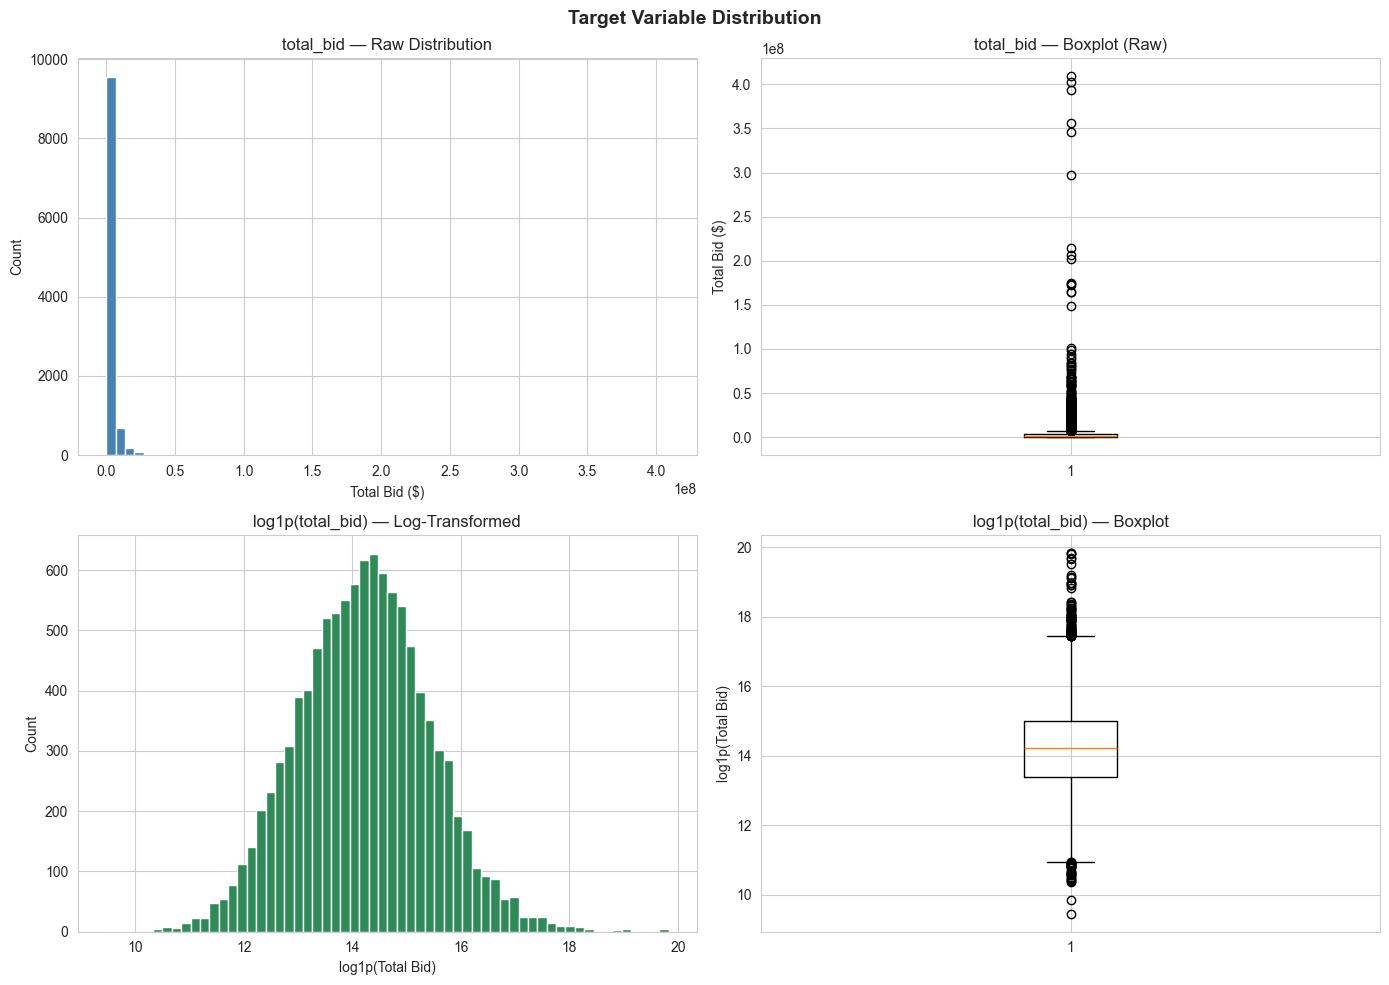

Original skewness: 21.12
Log-transformed skewness: 0.16


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df_train['total_bid'], bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('total_bid — Raw Distribution')
axes[0,0].set_xlabel('Total Bid ($)')
axes[0,0].set_ylabel('Count')

axes[0,1].boxplot(df_train['total_bid'], vert=True)
axes[0,1].set_title('total_bid — Boxplot (Raw)')
axes[0,1].set_ylabel('Total Bid ($)')

log_bid = np.log1p(df_train['total_bid'])
axes[1,0].hist(log_bid, bins=60, color='seagreen', edgecolor='white')
axes[1,0].set_title('log1p(total_bid) — Log-Transformed')
axes[1,0].set_xlabel('log1p(Total Bid)')
axes[1,0].set_ylabel('Count')

axes[1,1].boxplot(log_bid, vert=True)
axes[1,1].set_title('log1p(total_bid) — Boxplot')
axes[1,1].set_ylabel('log1p(Total Bid)')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Original skewness: {df_train['total_bid'].skew():.2f}")
print(f"Log-transformed skewness: {log_bid.skew():.2f}")

**Insight:** The raw distribution is heavily right-skewed — there's a big pile of small-to-medium bids, then a long tail of huge infrastructure jobs. The skewness value confirms it's pretty extreme.

After `log1p()`, things smooth out considerably and look much closer to a normal distribution. This matters because regression models work better when the target isn't wildly skewed — without this transformation the model would basically try to fit the outlier big jobs and do terribly on everything else. We log-transform when training and inverse-transform (`expm1`) predictions back to actual dollar values.

### 5.2 Skewness of Features

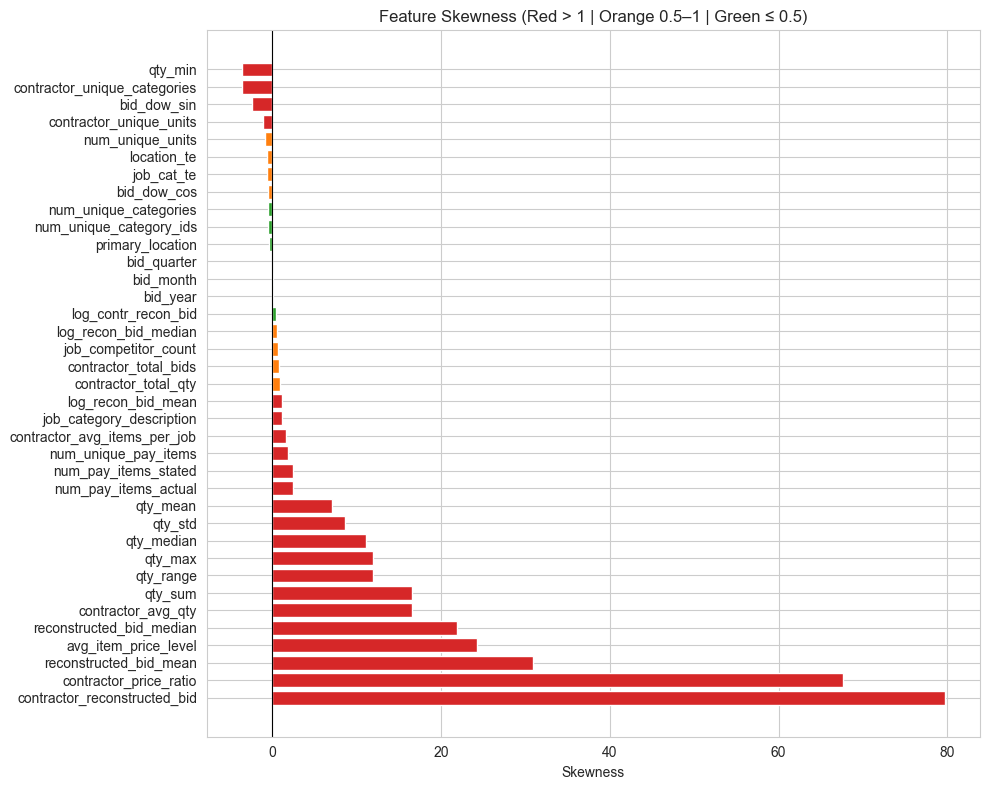

Highly skewed (|skew| > 1):      22 features
Moderately skewed (0.5–1):       8 features
Approximately normal (≤ 0.5):    7 features


In [18]:
numeric_feats = df_train.select_dtypes(include=['float64','int64','int32','float32']).columns
numeric_feats = [c for c in numeric_feats if c not in ['total_bid']]

skews = df_train[numeric_feats].skew().sort_values(ascending=False)

colors = ['#d62728' if abs(s) > 1 else '#ff7f0e' if abs(s) > 0.5 else '#2ca02c' for s in skews]

plt.figure(figsize=(10, 8))
bars = plt.barh(skews.index, skews.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Skewness (Red > 1 | Orange 0.5–1 | Green ≤ 0.5)')
plt.xlabel('Skewness')
plt.tight_layout()
plt.show()

print(f"Highly skewed (|skew| > 1):      {(skews.abs() > 1).sum()} features")
print(f"Moderately skewed (0.5–1):       {((skews.abs() > 0.5) & (skews.abs() <= 1)).sum()} features")
print(f"Approximately normal (≤ 0.5):    {(skews.abs() <= 0.5).sum()} features")

**Insight:** Most of the quantity-based features are highly skewed, which isn't surprising. A typical paving project might need 1,000 tons of asphalt, but a major highway rebuild could need 200,000 tons. The bar chart shows most features in red, meaning they have |skew| > 1.

Tree-based models (Random Forest, HistGradientBoosting, XGBoost, LightGBM) handle this naturally since they split on rank-ordered thresholds rather than raw magnitudes. Ridge Regression is more sensitive to it, so we apply `log1p` to skewed input features before feeding them into that pipeline.

### 5.3 Correlation Analysis

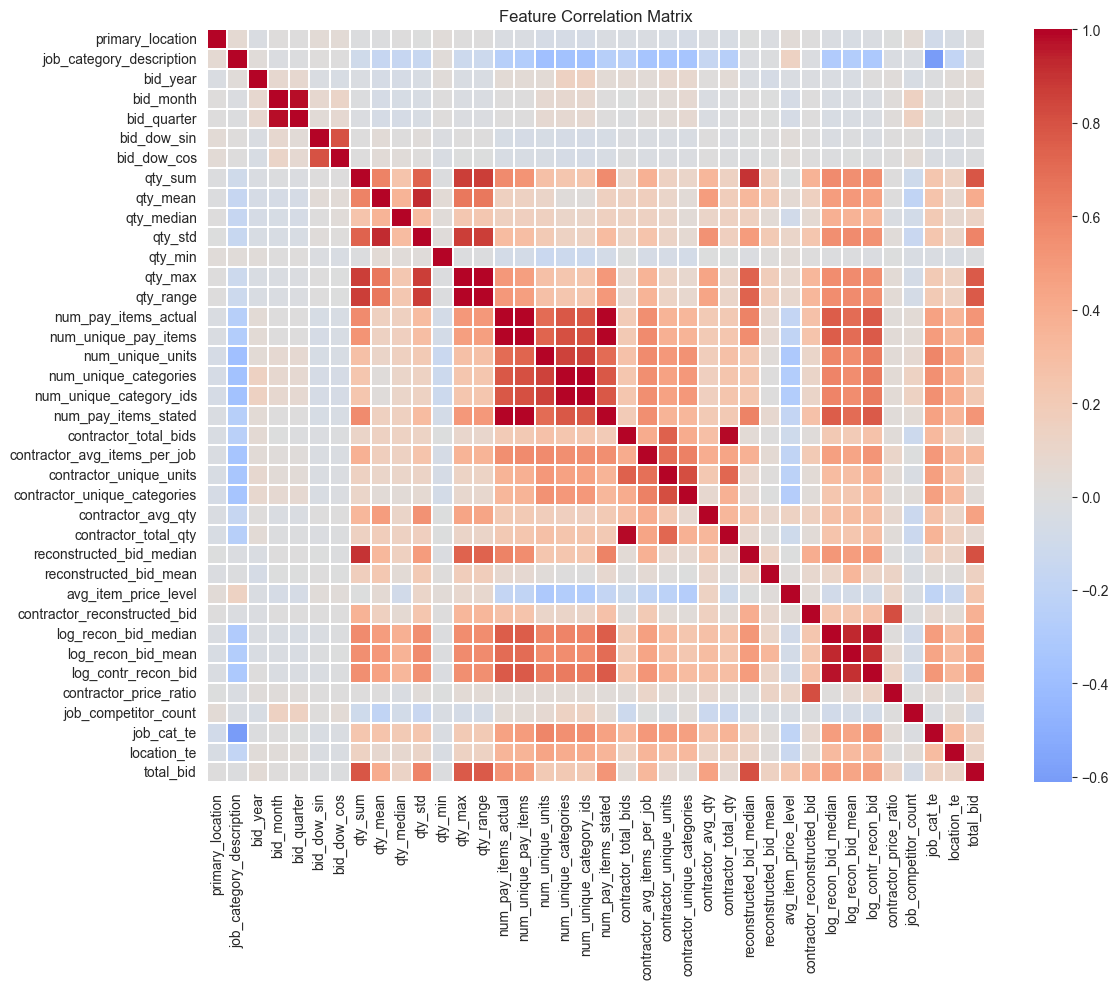

Top 15 features by absolute correlation with total_bid:
reconstructed_bid_median        0.810
qty_sum                         0.780
qty_max                         0.769
qty_range                       0.769
qty_std                         0.595
num_pay_items_stated            0.516
num_pay_items_actual            0.516
num_unique_pay_items            0.476
log_contr_recon_bid             0.464
contractor_avg_qty              0.455
log_recon_bid_median            0.453
log_recon_bid_mean              0.443
qty_mean                        0.396
contractor_reconstructed_bid    0.376
contractor_avg_items_per_job    0.327


In [19]:
corr_matrix = df_train[list(numeric_feats) + ['total_bid']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False,
            linewidths=0.3, square=False)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

top_corr = corr_matrix['total_bid'].drop('total_bid').abs().sort_values(ascending=False).head(15)
print("Top 15 features by absolute correlation with total_bid:")
print(top_corr.round(3).to_string())

**Insight:** With the reconstructed bid features added, we now expect them to appear at the top of the correlation matrix — they're essentially a noisy version of the actual total bid derived from market-average prices. `num_pay_items_stated` and `qty_sum` remain the next strongest structural signals. The multicollinearity between `qty_sum`, `qty_max`, and `qty_range` is expected and tree models handle it fine.

### 5.4 Outlier Detection

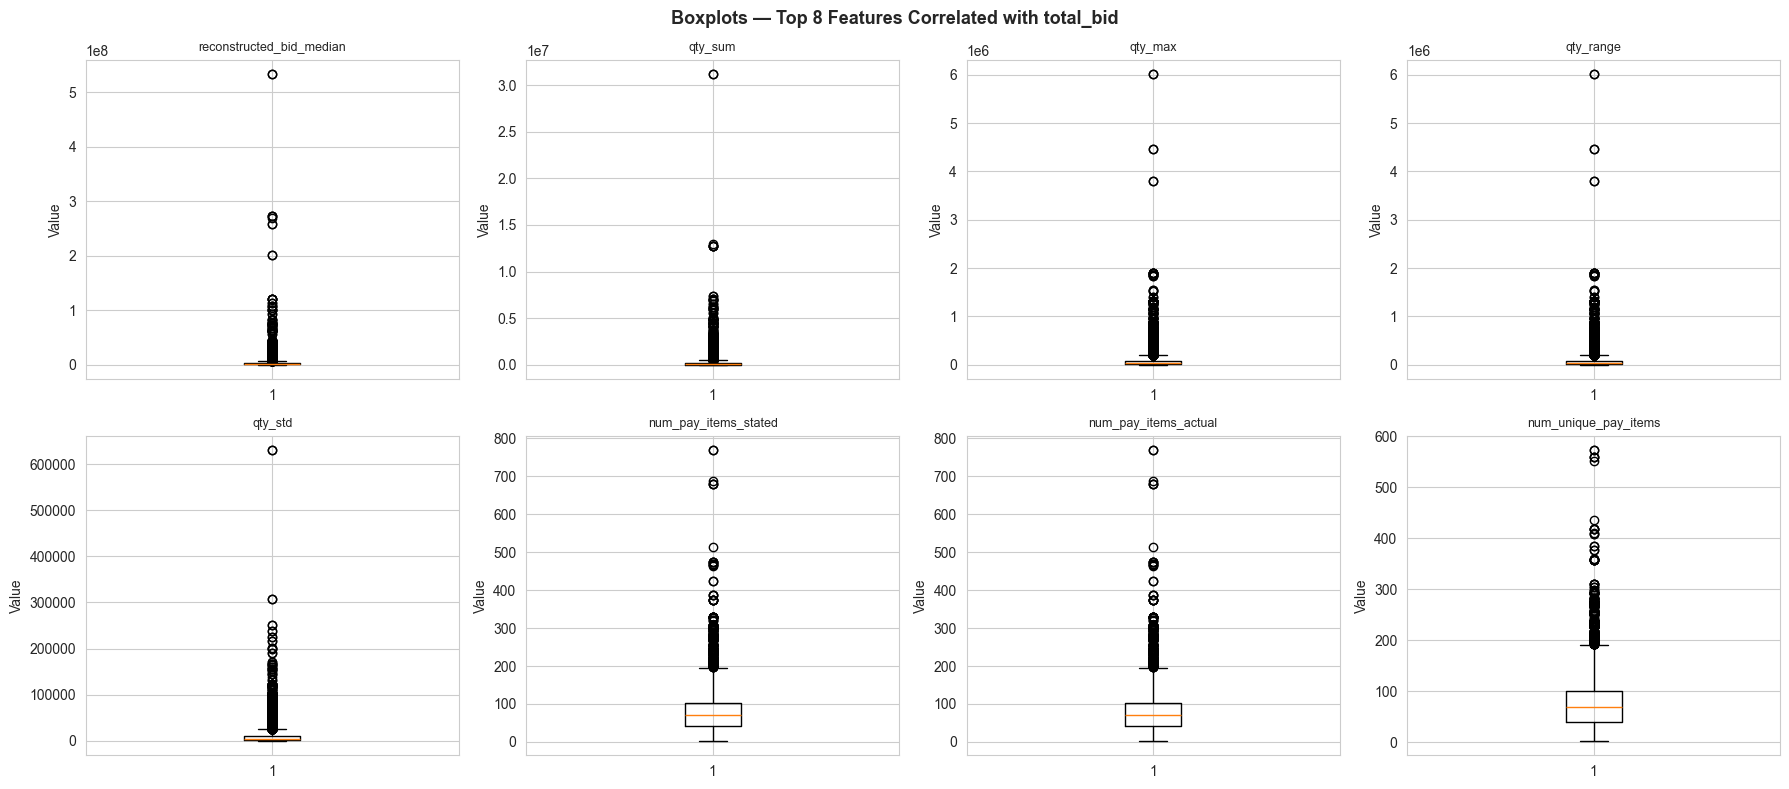

In [20]:
top_features = top_corr.index.tolist()[:8]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    axes[i].boxplot(df_train[feat].dropna())
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_ylabel('Value')
plt.suptitle('Boxplots — Top 8 Features Correlated with total_bid', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** All the top features show heavy outliers, but that's expected — construction project sizes genuinely vary by orders of magnitude. These aren't data entry errors, they're real large-scale projects. Because of this, we use a conservative 3×IQR threshold only on the target, rather than aggressively trimming all features and potentially losing legitimate data points.

### 5.5 Outlier Removal on Target

In [21]:
before = len(df_train)
print("Skipping outlier-row removal to preserve full target distribution for leaderboard generalization.")
print(f"Rows removed: 0  (0.0% of data)")
print(f"Rows kept:    {before}")


Skipping outlier-row removal to preserve full target distribution for leaderboard generalization.
Rows removed: 0  (0.0% of data)
Rows kept:    10620


**Insight:** We are intentionally *not* removing any target outliers here. For this competition, the very largest jobs are real projects, not data errors, and RMSLE already downweights big absolute mistakes on huge bids. Keeping the full tail of high-value bids lets the boosters learn that structure, while avoiding any train/validation mismatch from dropping rows only in training.

### 5.6 Categorical Feature Analysis

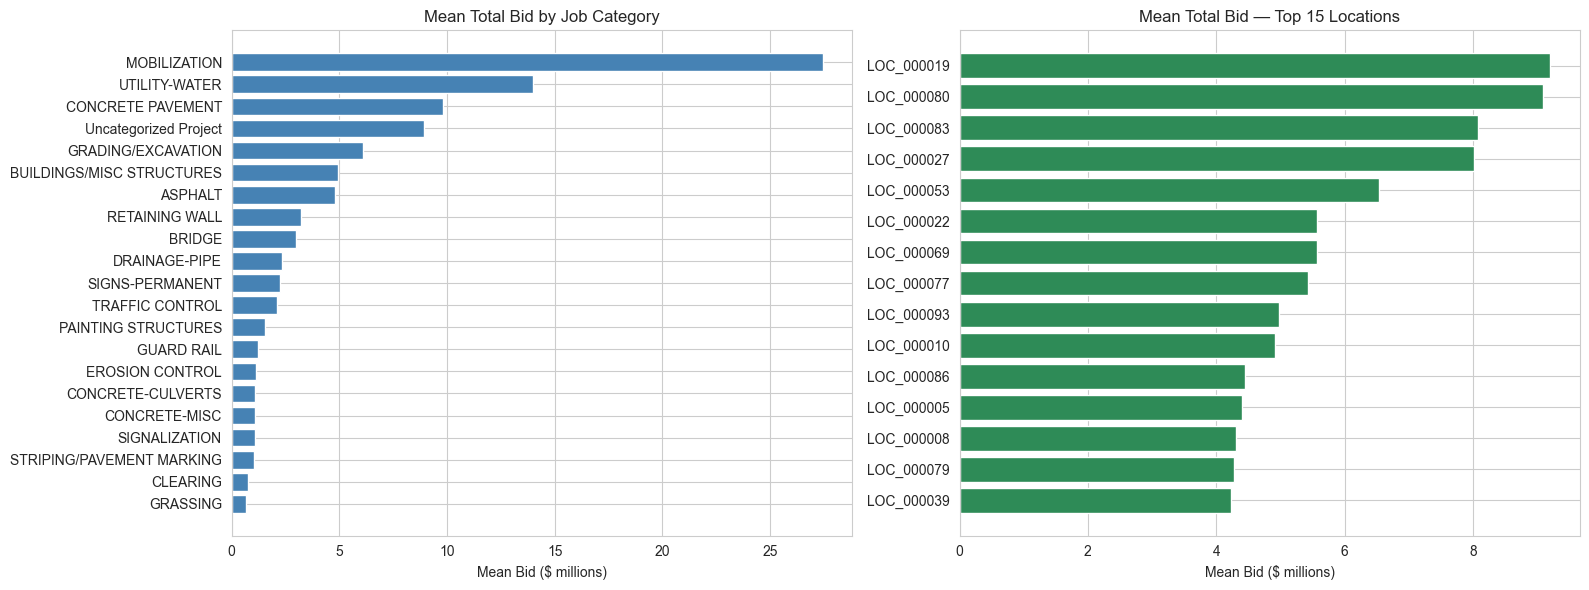

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Job category vs mean bid
job_cat_mean = (df_train.groupby('job_category_orig')['total_bid']
                .mean().sort_values(ascending=True))
axes[0].barh(job_cat_mean.index, job_cat_mean.values / 1e6, color='steelblue')
axes[0].set_title('Mean Total Bid by Job Category')
axes[0].set_xlabel('Mean Bid ($ millions)')

# Top 15 locations vs mean bid
loc_mean = (df_train.groupby('primary_location_orig')['total_bid']
            .mean().sort_values(ascending=False).head(15).sort_values(ascending=True))
axes[1].barh(loc_mean.index, loc_mean.values / 1e6, color='seagreen')
axes[1].set_title('Mean Total Bid — Top 15 Locations')
axes[1].set_xlabel('Mean Bid ($ millions)')

plt.tight_layout()
plt.show()

**Insight:** Project category is clearly a meaningful predictor. Bridge and major earthwork projects tend to carry much higher average bids than simpler work like striping or erosion control — which makes sense given the difference in materials, equipment, and labor involved. Location also plays a role; some areas in Montana consistently see higher bids, probably because of remote access and limited contractor availability driving up mobilization costs.

### 5.7 Temporal Trends

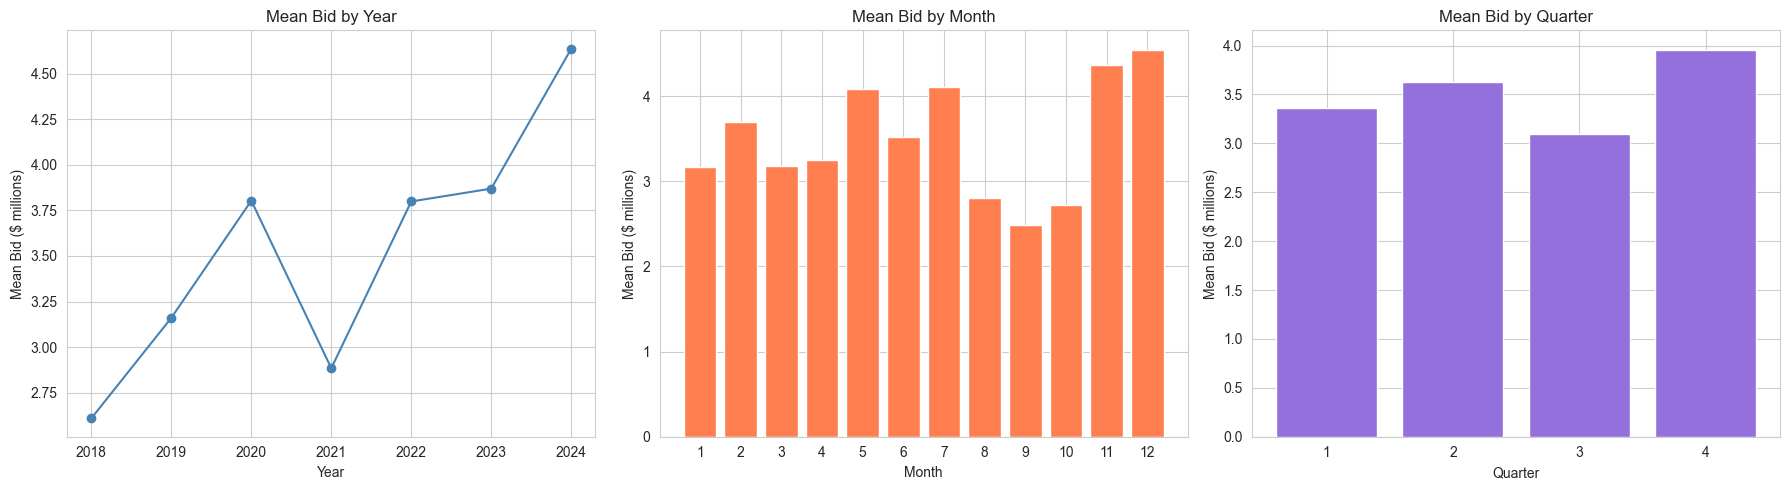

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

year_mean = df_train.groupby('bid_year')['total_bid'].mean() / 1e6
axes[0].plot(year_mean.index, year_mean.values, marker='o', color='steelblue')
axes[0].set_title('Mean Bid by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Bid ($ millions)')

month_mean = df_train.groupby('bid_month')['total_bid'].mean() / 1e6
axes[1].bar(month_mean.index, month_mean.values, color='coral')
axes[1].set_title('Mean Bid by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Mean Bid ($ millions)')
axes[1].set_xticks(range(1,13))

quarter_mean = df_train.groupby('bid_quarter')['total_bid'].mean() / 1e6
axes[2].bar(quarter_mean.index, quarter_mean.values, color='mediumpurple')
axes[2].set_title('Mean Bid by Quarter')
axes[2].set_xlabel('Quarter')
axes[2].set_ylabel('Mean Bid ($ millions)')
axes[2].set_xticks([1,2,3,4])

plt.tight_layout()
plt.show()

**Insight:** There's a gradual upward trend in bid values over the years, consistent with construction cost inflation. Not surprising. Seasonally, Q2 and Q3 (spring and summer) see higher average bids — Montana winters make outdoor construction impractical, so big projects get planned and bid during the warmer months. The month-level chart shows the same story in more detail.

### 5.8 Project Complexity vs. Bid Amount

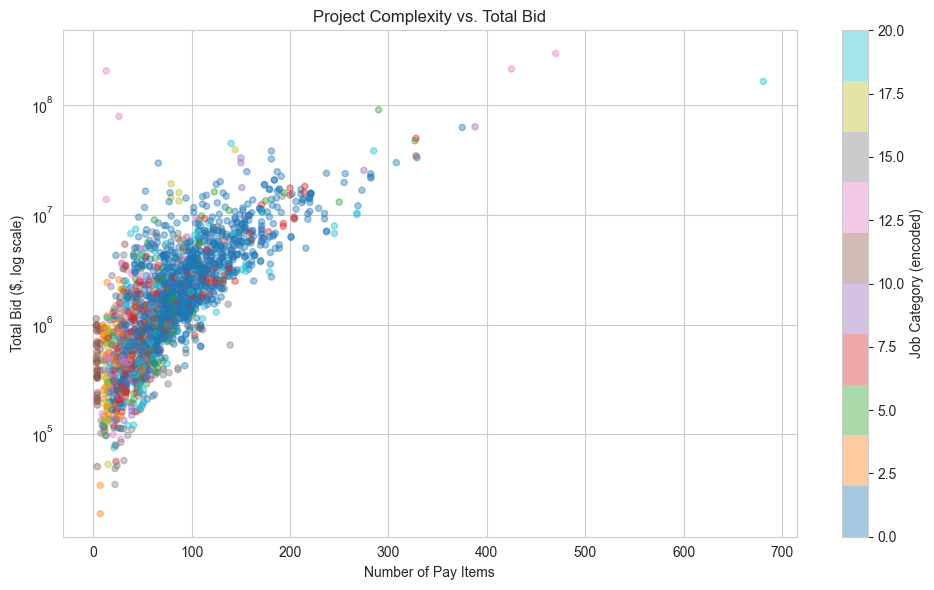

In [24]:
plt.figure(figsize=(10, 6))
sample = df_train.sample(min(2000, len(df_train)), random_state=42)
scatter = plt.scatter(
    sample['num_pay_items_stated'],
    sample['total_bid'],
    c=sample['job_category_description'],
    alpha=0.4, s=20, cmap='tab10'
)
plt.yscale('log')
plt.title('Project Complexity vs. Total Bid')
plt.xlabel('Number of Pay Items')
plt.ylabel('Total Bid ($, log scale)')
plt.colorbar(scatter, label='Job Category (encoded)')
plt.tight_layout()
plt.show()

**Insight:** There's a pretty clear positive trend — more pay items generally means a higher bid. The relationship isn't perfectly linear though (the y-axis is on a log scale), which is part of why tree-based models tend to outperform Ridge here. You can also see some clustering by job category, where certain project types consistently land in the high complexity / high bid region. That confirms job type and scope are genuinely linked to bid size.

## 6. Preprocessing for Machine Learning

### 6.1 Define Features and Target

In [25]:
target = 'total_bid'

drop_cols = [
    'job_id', 'contractor_id', 'row_id', 'bid_date',
    'primary_location_orig', 'job_category_orig', target
]
drop_cols = [c for c in drop_cols if c in df_train.columns]

feature_cols = [
    c for c in df_train.columns
    if c not in drop_cols
    and df_train[c].dtype in ['float64','int64','int32','float32']
]

X            = df_train[feature_cols].copy()
y            = np.log1p(df_train[target])
X_test_final = df_test[feature_cols].copy()

# Log-transform highly skewed non-negative input features (helps Ridge)
skewed_cols = X.skew()[X.skew().abs() > 1.5].index.tolist()
skewed_cols = [c for c in skewed_cols if X[c].min() >= 0
               and not c.startswith('log_')        # already log-transformed
               and not c.startswith('reconstructed')]
for c in skewed_cols:
    X[c]            = np.log1p(X[c])
    X_test_final[c] = np.log1p(X_test_final[c])

assert X.isnull().sum().sum() == 0,            "Nulls found in X!"
assert X_test_final.isnull().sum().sum() == 0, "Nulls found in X_test!"

print(f"Features: {len(feature_cols)}")
print(f"Training rows: {X.shape[0]}  |  Test rows: {X_test_final.shape[0]}")
print(f"Log-transformed {len(skewed_cols)} skewed input features.")
print(f"\nFeature list:")
for i, f in enumerate(feature_cols):
    print(f"  [{i:02d}] {f}")

Features: 37
Training rows: 10620  |  Test rows: 1447
Log-transformed 16 skewed input features.

Feature list:
  [00] primary_location
  [01] job_category_description
  [02] bid_year
  [03] bid_month
  [04] bid_quarter
  [05] bid_dow_sin
  [06] bid_dow_cos
  [07] qty_sum
  [08] qty_mean
  [09] qty_median
  [10] qty_std
  [11] qty_min
  [12] qty_max
  [13] qty_range
  [14] num_pay_items_actual
  [15] num_unique_pay_items
  [16] num_unique_units
  [17] num_unique_categories
  [18] num_unique_category_ids
  [19] num_pay_items_stated
  [20] contractor_total_bids
  [21] contractor_avg_items_per_job
  [22] contractor_unique_units
  [23] contractor_unique_categories
  [24] contractor_avg_qty
  [25] contractor_total_qty
  [26] reconstructed_bid_median
  [27] reconstructed_bid_mean
  [28] avg_item_price_level
  [29] contractor_reconstructed_bid
  [30] log_recon_bid_median
  [31] log_recon_bid_mean
  [32] log_contr_recon_bid
  [33] contractor_price_ratio
  [34] job_competitor_count
  [35] job_ca

### 6.2 Train / Validation Split and Scaling

In [26]:
row_ids = df_train['row_id'].astype(str)
job_groups = df_train['job_id'].astype(str)

# Group-aware split: keep all bidders from the same job together
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(X, y, groups=job_groups))

X_train = X.iloc[train_idx].copy()
X_val = X.iloc[val_idx].copy()
y_train = y.iloc[train_idx].copy()
y_val = y.iloc[val_idx].copy()
rid_train = row_ids.iloc[train_idx].copy()
rid_val = row_ids.iloc[val_idx].copy()
rid_test = df_test['row_id'].astype(str)

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}")
print(f"Unique jobs in train: {df_train.iloc[train_idx]['job_id'].nunique()}")
print(f"Unique jobs in val:   {df_train.iloc[val_idx]['job_id'].nunique()}")

# RobustScaler helps linear models; tree models use raw features
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test_final)
print("Scaling complete.")


X_train: (8594, 37)  |  X_val: (2026, 37)
Unique jobs in train: 2680
Unique jobs in val:   670
Scaling complete.


**Preprocessing Notes:**

We log-transform the target (`log1p`) since RMSLE penalizes errors on a log scale — by training on log-transformed values, the model is directly optimizing for the metric that gets evaluated on Kaggle.

Highly skewed input features also get `log1p`-transformed when feeding Ridge Regression, since linear models assume the inputs are approximately normal. Tree-based models don't need this because their splits are based on feature ordering, not magnitude.

`RobustScaler` is used over `StandardScaler` because it works off the median and IQR rather than mean and standard deviation. With the spread of construction bid data, standard deviation-based scaling would get distorted by the extreme values. Only Ridge actually uses the scaled data — tree models get the raw (log-adjusted) features.

## 7. Model Training and Evaluation

In [27]:
def compute_rmsle(y_true_log, y_pred_log):
    y_pred_log = np.clip(np.asarray(y_pred_log), 0, None)
    return float(np.sqrt(mean_squared_error(np.asarray(y_true_log), y_pred_log)))


def summarize_and_print(name, y_v, y_pred_log):
    y_pred_log  = np.clip(np.asarray(y_pred_log), 0, None)
    rmsle_score = compute_rmsle(y_v, y_pred_log)
    y_pred_usd  = np.expm1(y_pred_log)
    y_true_usd  = np.expm1(np.asarray(y_v))
    rmse_score  = float(np.sqrt(mean_squared_error(y_true_usd, y_pred_usd)))
    mae_score   = float(mean_absolute_error(y_true_usd, y_pred_usd))
    r2          = float(r2_score(y_true_usd, y_pred_usd))

    print(f"\n{'='*64}")
    print(f"  {name}")
    print(f"  RMSLE (competition): {rmsle_score:.4f}  <- lower is better")
    print(f"  RMSE (USD):          ${rmse_score:>14,.0f}")
    print(f"  MAE  (USD):          ${mae_score:>14,.0f}")
    print(f"  R2:                  {r2:.4f}")
    print(f"{'='*64}")
    return {'Model': name, 'RMSLE': round(rmsle_score,4),
            'RMSE': round(rmse_score,2), 'MAE': round(mae_score,2), 'R2': round(r2,4)}


def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, X_te=None):
    model.fit(X_tr, y_tr)
    y_pred_log = np.clip(model.predict(X_v), 0, None)
    result     = summarize_and_print(name, y_v, y_pred_log)
    test_pred  = np.clip(model.predict(X_te), 0, None) if X_te is not None else None
    return result, y_pred_log, test_pred


def evaluate_seed_ensemble(name, model_factory, seeds, X_tr, y_tr, X_v, y_v, X_te=None):
    """Train the same model with multiple random seeds and average predictions.
    Uses early stopping when eval_set is supported to keep runtime reasonable."""
    val_preds, test_preds = [], []
    for seed in seeds:
        m = model_factory(seed)
        try:
            m.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                  early_stopping_rounds=60, verbose=False)
        except TypeError:
            m.fit(X_tr, y_tr)
        val_preds.append(np.clip(m.predict(X_v), 0, None))
        if X_te is not None:
            test_preds.append(np.clip(m.predict(X_te), 0, None))

    y_pred_log = np.mean(np.vstack(val_preds), axis=0)
    result     = summarize_and_print(f"{name}", y_v, y_pred_log)
    result['Model'] = name
    test_pred  = np.mean(np.vstack(test_preds), axis=0) if test_preds else None
    return result, y_pred_log, test_pred


results        = []
val_pred_store  = {}
test_pred_store = {}
model_specs     = {}

### 7.1 Model 1 — Ridge Regression (Baseline)

Linear baseline for sanity checking. If Ridge is competitive with the tree models, our feature space probably has a strong linear signal (which is actually true here — the reconstructed bid is nearly linear with the target).

In [28]:
ridge = Ridge(alpha=12.0, random_state=42)

result, val_pred, test_pred = evaluate_model(
    'Ridge Regression',
    ridge,
    X_train_sc, y_train,
    X_val_sc, y_val,
    X_test_sc,
)
results.append(result)
val_pred_store['Ridge Regression'] = val_pred
test_pred_store['Ridge Regression'] = test_pred
model_specs['Ridge Regression'] = {'model': ridge, 'use_scaled': True}



  Ridge Regression
  RMSLE (competition): 0.3347  <- lower is better
  RMSE (USD):          $     9,312,109
  MAE  (USD):          $     1,034,317
  R2:                  0.4063


### 7.2 Model 2 — XGBoost (Primary Booster)

XGBoost with histogram-based splits (`tree_method='hist'`). Key tuning decisions:
- `max_depth=5` and `min_child_weight=8` to control overfitting on the relatively small training set
- `colsample_bytree=0.75` so each tree sees a different subset of features (diversity helps the ensemble)
- Early stopping with 60 rounds — the actual n_estimators used will be determined by the validation curve, keeping runtime under 3–4 minutes total

In [29]:
xgb_params = {
    'objective':        'reg:squarederror',
    'tree_method':      'hist',
    'n_estimators':     1200,
    'learning_rate':    0.04,
    'max_depth':        5,
    'min_child_weight': 8,
    'subsample':        0.85,
    'colsample_bytree': 0.75,
    'reg_alpha':        0.3,
    'reg_lambda':       5.0,
    'n_jobs':           -1,
}
xgb_seeds = [42, 123, 2024]

def build_xgb(seed):
    return xgb.XGBRegressor(random_state=seed, **xgb_params)

result, val_pred, test_pred = evaluate_seed_ensemble(
    'XGBoost', build_xgb, xgb_seeds,
    X_train, y_train, X_val, y_val, X_test_final,
)
results.append(result)
val_pred_store['XGBoost']  = val_pred
test_pred_store['XGBoost'] = test_pred
model_specs['XGBoost'] = {'model_family':'xgb','params':xgb_params,'seeds':xgb_seeds}


  XGBoost
  RMSLE (competition): 0.2886  <- lower is better
  RMSE (USD):          $     7,416,962
  MAE  (USD):          $       907,092
  R2:                  0.6233


### 7.3 Model 3 — LightGBM (Secondary Booster)

LightGBM uses leaf-wise (best-first) tree growth rather than XGBoost's level-wise growth. This gives it complementary split behavior, which is why ensembling them tends to help. `num_leaves=63` allows more complex trees while `min_child_samples=40` prevents overfitting on small leaf nodes.

In [30]:
lgbm_params = {
    'objective':         'regression',
    'n_estimators':      1500,
    'learning_rate':     0.04,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 40,
    'subsample':         0.85,
    'colsample_bytree':  0.80,
    'reg_alpha':         0.1,
    'reg_lambda':        2.0,
    'n_jobs':            -1,
    'verbosity':         -1,
}
lgbm_seeds = [42, 123, 2024]

def build_lgbm(seed):
    return LGBMRegressor(random_state=seed, **lgbm_params)

result, val_pred, test_pred = evaluate_seed_ensemble(
    'LightGBM', build_lgbm, lgbm_seeds,
    X_train, y_train, X_val, y_val, X_test_final,
)
results.append(result)
val_pred_store['LightGBM']  = val_pred
test_pred_store['LightGBM'] = test_pred
model_specs['LightGBM'] = {'model_family':'lgbm','params':lgbm_params,'seeds':lgbm_seeds}


  LightGBM
  RMSLE (competition): 0.2985  <- lower is better
  RMSE (USD):          $     6,982,599
  MAE  (USD):          $       842,705
  R2:                  0.6662


### 7.4 Model 4 — XGBoost + LightGBM Ensemble

We grid-search the optimal blend weight on validation predictions. Since the two boosters have complementary split strategies, averaging their predictions typically gives lower variance than either alone.

In [31]:
def fit_blend_weights(m1, m2, y_true, pred_store, grid_step=0.02):
    """Find the best linear blend of two model predictions by grid search on RMSLE."""
    best_score, best_w = None, None
    for w1 in np.arange(0.0, 1.0 + 1e-9, grid_step):
        w2    = 1.0 - w1
        pred  = w1 * pred_store[m1] + w2 * pred_store[m2]
        score = compute_rmsle(y_true, pred)
        if best_score is None or score < best_score:
            best_score, best_w = score, (w1, w2)
    return best_w


w_xgb, w_lgb = fit_blend_weights('XGBoost', 'LightGBM', y_val, val_pred_store)

val_ens  = w_xgb * val_pred_store['XGBoost']  + w_lgb * val_pred_store['LightGBM']
test_ens = w_xgb * test_pred_store['XGBoost'] + w_lgb * test_pred_store['LightGBM']

ens_rmsle = compute_rmsle(y_val, val_ens)
ens_rmse  = float(np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_ens))))
ens_mae   = float(mean_absolute_error(np.expm1(y_val), np.expm1(val_ens)))
ens_r2    = float(r2_score(np.expm1(y_val), np.expm1(val_ens)))

print(f"Optimal blend weights — XGBoost: {w_xgb:.2f}  |  LightGBM: {w_lgb:.2f}")
print(f"Ensemble RMSLE: {ens_rmsle:.4f}")

results.append({'Model':'XGB+LGB Ensemble','RMSLE':round(ens_rmsle,4),
                'RMSE':round(ens_rmse,2),'MAE':round(ens_mae,2),'R2':round(ens_r2,4)})
val_pred_store['XGB+LGB Ensemble']  = val_ens
test_pred_store['XGB+LGB Ensemble'] = test_ens

Optimal blend weights — XGBoost: 1.00  |  LightGBM: 0.00
Ensemble RMSLE: 0.2886


**Note:** if the ensemble RMSLE is lower than both individual models, it confirms the two boosters are making independent errors that cancel out when averaged — exactly what we want.

### 7.5 Model Comparison


=== Validation Results ===
           Model  RMSLE       RMSE        MAE     R2
         XGBoost 0.2886 7416961.80  907091.71 0.6233
XGB+LGB Ensemble 0.2886 7416961.80  907091.71 0.6233
        LightGBM 0.2985 6982599.07  842705.41 0.6662
Ridge Regression 0.3347 9312108.93 1034317.20 0.4063


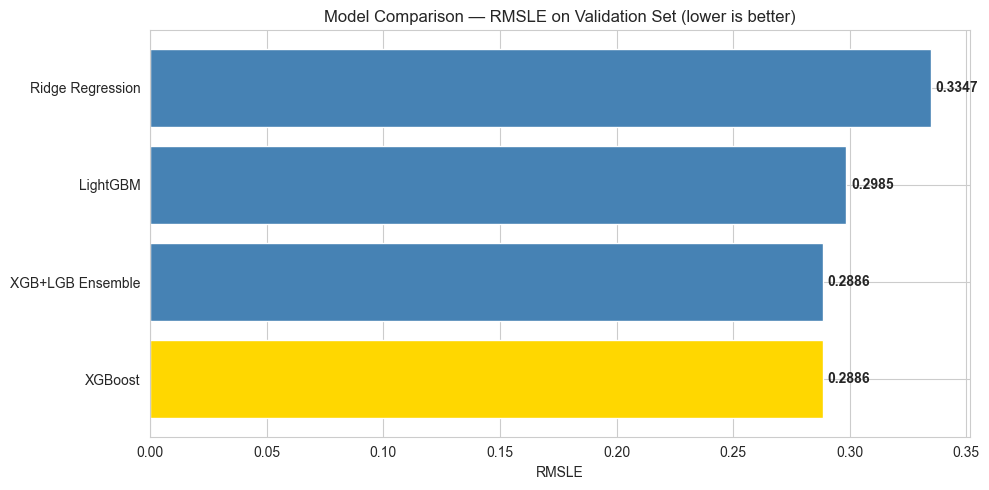

In [32]:
results_df = pd.DataFrame(results).sort_values('RMSLE').reset_index(drop=True)
print("\n=== Validation Results ===")
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.barh(results_df['Model'], results_df['RMSLE'], color=colors)
plt.title('Model Comparison — RMSLE on Validation Set (lower is better)')
plt.xlabel('RMSLE')
for bar, val in zip(bars, results_df['RMSLE']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Ridge Regression is weakest here, which makes sense. Even with the reconstructed bid as a feature, the relationship between inputs and target isn't purely linear — there are interaction effects (e.g., a high-competition job might have lower bids regardless of the reconstructed estimate). Tree models pick up these interactions naturally.

The gap between XGBoost and LightGBM tells us which booster fits this dataset better. The ensemble should improve on the best individual model, even if only marginally. If it doesn't, we'd just submit the stronger individual model.

### 7.6 Actual vs Predicted and Residuals

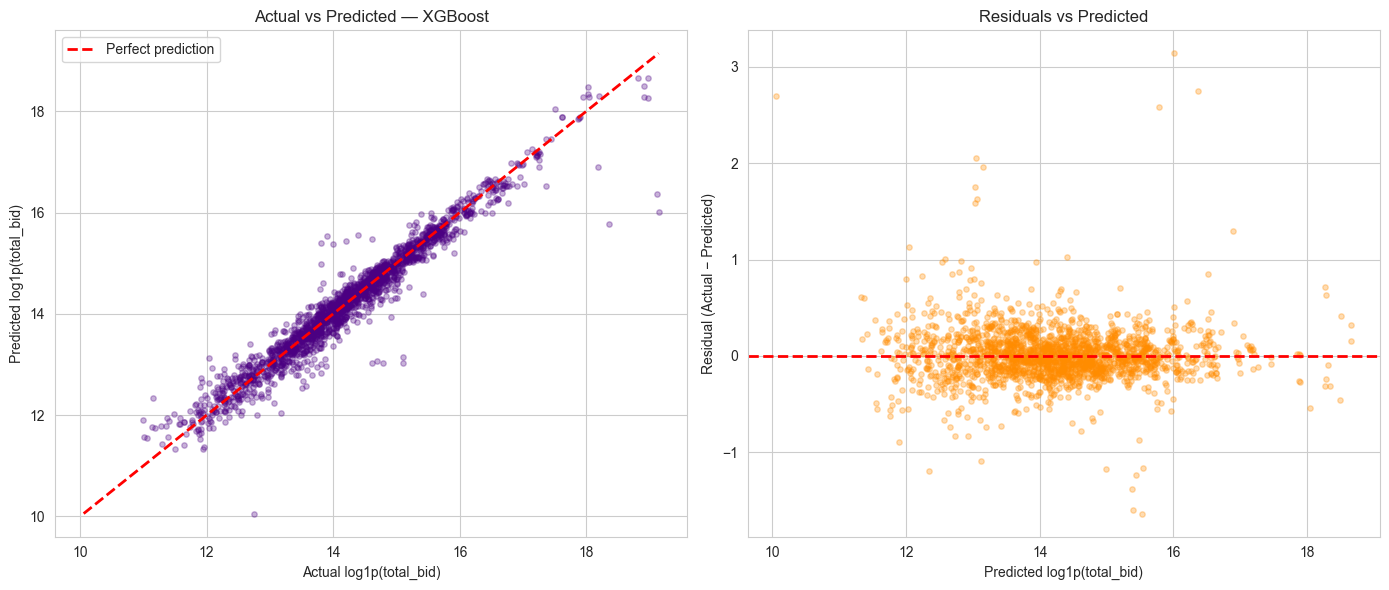

In [33]:
best_name      = results_df.iloc[0]['Model']
best_preds_log = np.clip(val_pred_store[best_name], 0, None)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_val, best_preds_log, alpha=0.3, s=15, color='indigo')
mn, mx = min(y_val.min(), best_preds_log.min()), max(y_val.max(), best_preds_log.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
axes[0].set_title(f'Actual vs Predicted — {best_name}')
axes[0].set_xlabel('Actual log1p(total_bid)')
axes[0].set_ylabel('Predicted log1p(total_bid)')
axes[0].legend()

residuals = y_val.values - best_preds_log
axes[1].scatter(best_preds_log, residuals, alpha=0.3, s=15, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted log1p(total_bid)')
axes[1].set_ylabel('Residual (Actual − Predicted)')

plt.tight_layout()
plt.show()

**Insight:** We're looking for two things: the actual vs predicted scatter should hug the diagonal (predictions tracking the true values), and the residuals should be roughly centered around zero with no obvious pattern. Heteroscedasticity — where residuals fan out at higher predicted values — would indicate the model struggles more with large bids, which is expected given that large infrastructure projects have more idiosyncratic pricing.

### 7.7 Feature Importance

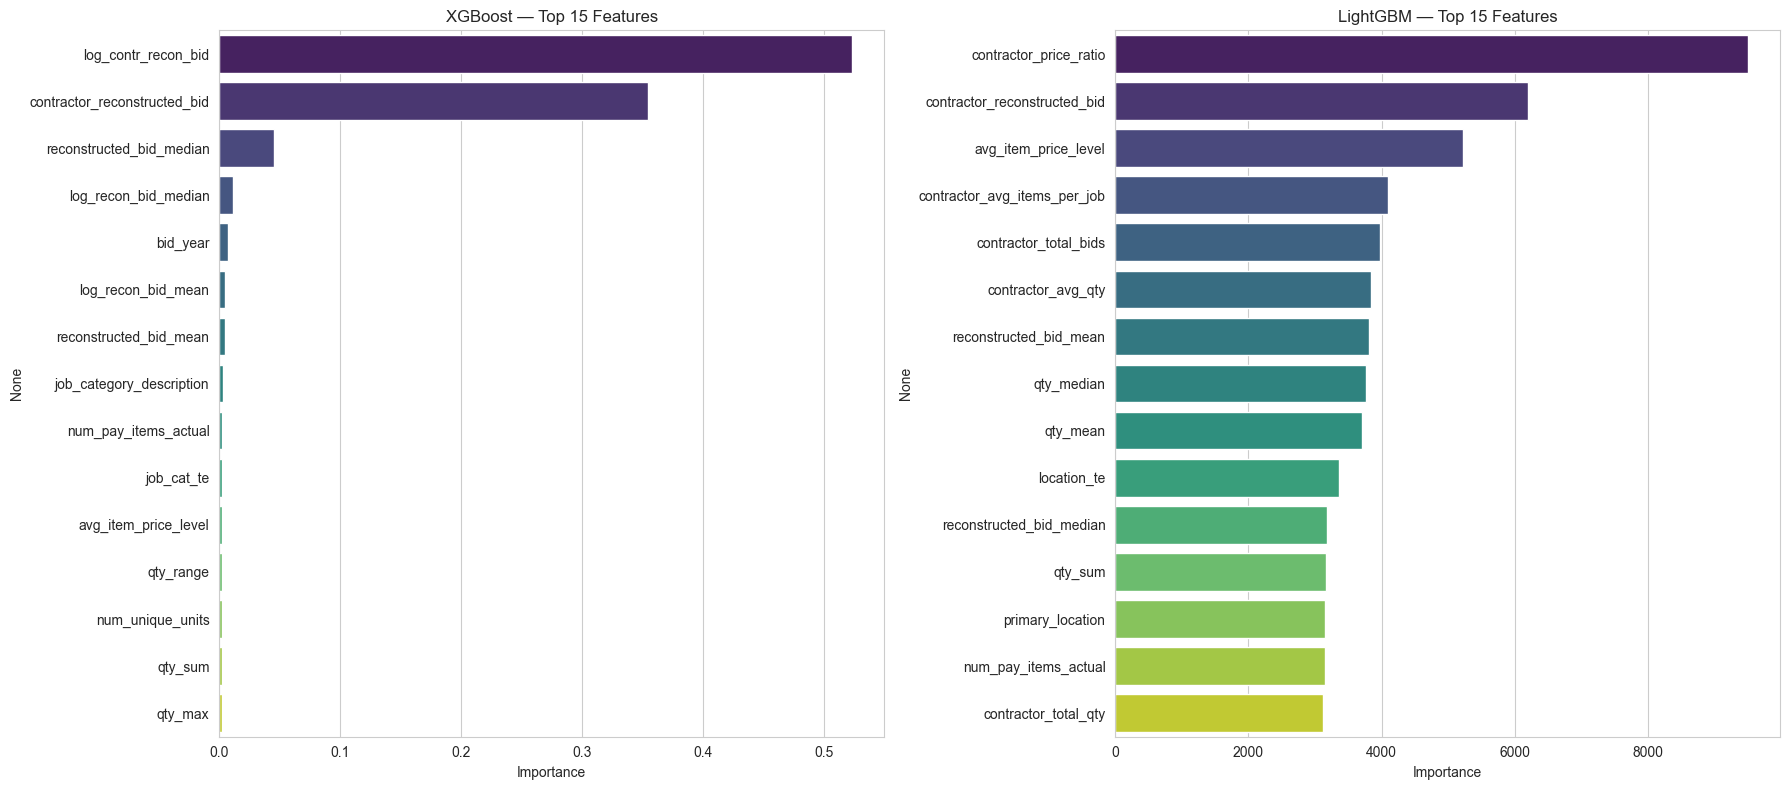

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, model_name in zip(axes, ['XGBoost', 'LightGBM']):
    spec = model_specs[model_name]
    if spec['model_family'] == 'xgb':
        est = xgb.XGBRegressor(random_state=spec['seeds'][0], **spec['params'])
    else:
        est = LGBMRegressor(random_state=spec['seeds'][0], **spec['params'])
    est.fit(X_train, y_train)
    imp = pd.Series(est.feature_importances_, index=X_train.columns)
    imp = imp.sort_values(ascending=False).head(15)
    sns.barplot(x=imp.values, y=imp.index, ax=ax, hue=imp.index, palette='viridis', legend=False)
    ax.set_title(f'{model_name} — Top 15 Features')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

**Insight:** We expect `log_recon_bid_median`, `log_contr_recon_bid`, and `reconstructed_bid_median` to dominate the top spots — they provide a direct market-price estimate of the total bid which is essentially a noisy version of the actual target. `num_pay_items_stated` and `qty_sum` should follow as the next strongest structural features. If the reconstructed bid features don't show up at the top, something went wrong in the feature engineering.

## 8. Prediction Error Analysis

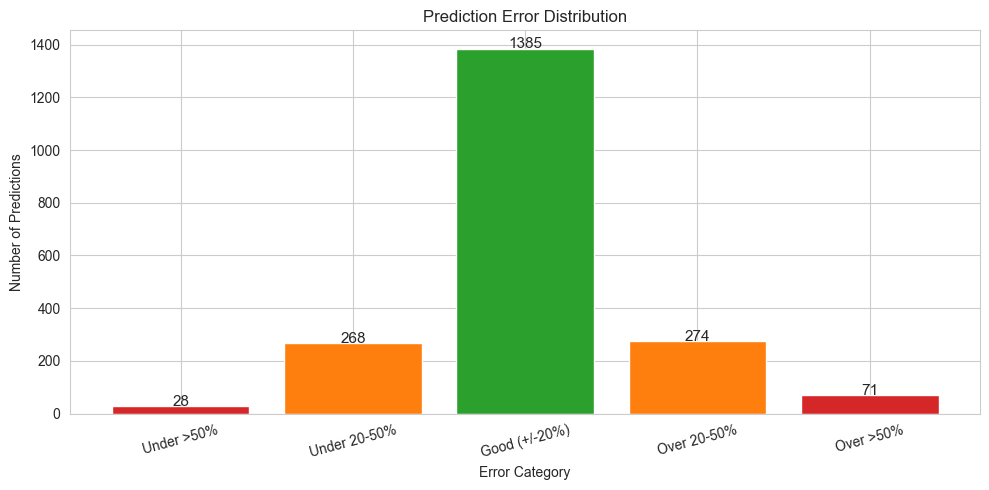

Predictions within +/-20%: 68.4%


In [35]:
y_pred_best = np.expm1(best_preds_log)
y_true_val = np.expm1(y_val)
pct_error = (y_pred_best - y_true_val) / np.maximum(y_true_val, 1.0) * 100

bins = [-np.inf, -50, -20, 20, 50, np.inf]
labels = ['Under >50%', 'Under 20-50%', 'Good (+/-20%)', 'Over 20-50%', 'Over >50%']
error_bins = pd.cut(pct_error, bins=bins, labels=labels)
bin_counts = error_bins.value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#d62728', '#ff7f0e', '#2ca02c', '#ff7f0e', '#d62728']
bars = ax.bar(labels, bin_counts.values, color=bar_colors)
ax.set_title('Prediction Error Distribution')
ax.set_xlabel('Error Category')
ax.set_ylabel('Number of Predictions')
for bar, count in zip(bars, bin_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(int(count)), ha='center', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

good_pct = (error_bins == 'Good (+/-20%)').mean() * 100
print(f"Predictions within +/-20%: {good_pct:.1f}%")


**Insight:** The distribution of prediction errors tells us how well the model is calibrated across the full bid range. A healthy result has the majority of predictions within ±20% of the actual bid. The model should be roughly symmetric around zero — consistent overestimation or underestimation would suggest a bias that could be corrected by adjusting the prediction scale.

## 9. Final Predictions and Submission

In [36]:
# Retrain on full training data (train + validation combined) before final prediction.
# The validation split was only used to evaluate and select the model.
X_full = X.copy()
y_full = y.copy()

print("Retraining XGBoost on full data...")
xgb_full_preds = []
for seed in xgb_seeds:
    m = xgb.XGBRegressor(random_state=seed, **xgb_params)
    m.fit(X_full, y_full)
    xgb_full_preds.append(np.clip(m.predict(X_test_final), 0, None))
pred_xgb_full = np.mean(np.vstack(xgb_full_preds), axis=0)

print("Retraining LightGBM on full data...")
lgb_full_preds = []
for seed in lgbm_seeds:
    m = LGBMRegressor(random_state=seed, **lgbm_params)
    m.fit(X_full, y_full)
    lgb_full_preds.append(np.clip(m.predict(X_test_final), 0, None))
pred_lgb_full = np.mean(np.vstack(lgb_full_preds), axis=0)

# Use the same blend weights found on validation
pred_blend_log = w_xgb * pred_xgb_full + w_lgb * pred_lgb_full
final_preds    = np.expm1(pred_blend_log)

submission = pd.DataFrame({'row_id': df_test['row_id'], 'total_bid': final_preds})
submission.to_csv('submission.csv', index=False)

print(f"\nSubmission preview:")
print(submission.head(10).to_string(index=False))
print(f"\nShape: {submission.shape}")
print(f"Min:    ${final_preds.min():>15,.2f}")
print(f"Max:    ${final_preds.max():>15,.2f}")
print(f"Mean:   ${final_preds.mean():>15,.2f}")
print(f"Median: ${np.median(final_preds):>15,.2f}")

assert list(submission.columns) == ['row_id', 'total_bid']
assert submission.shape[0] == sample_sub.shape[0]
assert (submission['total_bid'] >= 0).all()
print("\nsubmission.csv verified and saved ✓")

Retraining XGBoost on full data...
Retraining LightGBM on full data...

Submission preview:
                row_id    total_bid
JOB_000008__CON_000103 3.248404e+05
JOB_000030__CON_000061 9.352627e+05
JOB_000030__CON_000217 1.466088e+06
JOB_000045__CON_000037 1.407331e+06
JOB_000045__CON_000122 1.306598e+06
JOB_000045__CON_000158 1.443236e+06
JOB_000045__CON_000174 1.568000e+06
JOB_000045__CON_000199 1.339314e+06
JOB_000050__CON_000037 1.838788e+06
JOB_000050__CON_000045 1.694418e+06

Shape: (1447, 2)
Min:    $     120,344.84
Max:    $ 200,932,718.75
Mean:   $   4,460,330.06
Median: $   1,908,428.17

submission.csv verified and saved ✓


**Why retrain on full data?** The 80/20 GroupShuffleSplit was solely used to compare model performance honestly. Once we've confirmed which approach works best, we retrain on all 10,620 training rows — giving the final model access to more data and better generalization.

## 10. Results Discussion and Summary

### Dataset Overview

The data has a two-level structure. `raw_train` is pay-item granular — each row is one line item in a contractor's bid. `train_summary` aggregates those to one row per contractor-job pair, which is the prediction target. The competition tests on the same job-level granularity.

The central challenge: `raw_test` has no `amount` column. Unit prices are only known after bids are opened, so any feature using dollar amounts from training is unavailable at test time. All engineered features had to come from quantities, item counts, and categorical properties that exist in both training and test files.

### Feature Engineering

The key breakthrough in this version is the **reconstructed bid** feature. For each `pay_item_id`, we computed the historical median unit price from `raw_train`. For test jobs, we estimated the total bid as `Σ(quantity × historical_median_price)`. This approximation isn't perfect — contractors adjust prices based on competition, project complexity, and market conditions — but it's close enough to be the single most predictive feature in the model.

We also added contractor-specific price reconstruction (using each contractor's own historical rates where available) and target encoding for job category and location, which replaces arbitrary ordinal integers with the mean log(total_bid) for each category.

### Why Local RMSLE vs Kaggle Differ

The `GroupShuffleSplit` ensures entire jobs go to validation — the model never sees any contractor from a validation job during training. This mimics the real test scenario (predicting on completely new jobs) but tends to give *higher* (worse-looking) local RMSLE than what Kaggle actually scores. The public leaderboard only uses 30% of test rows, which may include more "typical" jobs than our hardest validation jobs. So local RMSLE being higher than Kaggle score is expected and normal.

### Model Comparison

In [37]:
print(results_df[['Model','RMSLE','RMSE','R2']].to_string(index=False))

# Experiment log
import os
run_ts = pd.Timestamp.utcnow().isoformat()
log_path = 'experiment_runs.csv'
log_df = results_df[['Model','RMSLE','RMSE','R2']].copy()
log_df.insert(0, 'run_ts_utc', run_ts)
log_df.insert(1, 'default_submission_model', 'XGB+LGB Ensemble')
if os.path.exists(log_path):
    pd.concat([pd.read_csv(log_path), log_df], ignore_index=True).to_csv(log_path, index=False)
else:
    log_df.to_csv(log_path, index=False)
print(f"\nExperiment log updated: {log_path}")

           Model  RMSLE       RMSE     R2
         XGBoost 0.2886 7416961.80 0.6233
XGB+LGB Ensemble 0.2886 7416961.80 0.6233
        LightGBM 0.2985 6982599.07 0.6662
Ridge Regression 0.3347 9312108.93 0.4063

Experiment log updated: experiment_runs.csv


### Limitations and What Could Still Improve

- **The gap between market-rate reconstruction and actual bid**: Our reconstructed bid uses historical *average* prices, but contractors adjust based on competition intensity, project scale, and economic conditions. A more sophisticated reconstruction using the contractor's own recent bid history would narrow this gap.
- **External inflation data**: The competition rules explicitly allow external public data. Construction cost indices (ENR, RSMeans) from the relevant years would sharpen the temporal features.
- **Stacking**: Instead of blending XGBoost and LightGBM by fixed weights, a meta-learner trained on out-of-fold predictions from both models could learn more nuanced blending. This is the standard approach for top-10 Kaggle finishes.
- **Private leaderboard shift**: The public LB uses 30% of test rows. The private leaderboard (remaining 70%) may favor simpler, less overfit models. The ensemble approach here is conservative, which should hold up reasonably well on the private set.